# SUMMA Streamflow Point-Scale Evaluation

## Introduction

This notebook demonstrates how to evaluate SUMMA model streamflow outputs against observed streamflow data using the `cssi_evaluation` framework.

**Domain:** Bow River at Banff, Alberta, Canada (WSC Station 05BB001)

**Data source:** SUMMA simulation outputs from the [SYMFLUENCE](https://github.com/DarriEy/SYMFLUENCE) framework, using RDRS forcing data over the period 2002-2009.

### Two evaluation approaches are demonstrated:

1. **Lumped SUMMA** — Single-HRU domain with `averageRoutedRunoff` extracted via `get_summa_streamflow()` (DDS-calibrated)
2. **Semi-distributed SUMMA + mizuRoute** — Multi-HRU domain (25 HRUs, 13 GRUs) with routed streamflow extracted via `get_mizuroute_streamflow()` at a specific river segment (uncalibrated baseline)

## Part 1: Lumped SUMMA Evaluation (DDS-calibrated)

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add the cssi_evaluation source to the path
sys.path.insert(0, os.path.abspath("../../src"))

from cssi_evaluation.models.summa_utils import (
    get_summa_output,
    get_summa_streamflow,
    get_mizuroute_streamflow,
)
from cssi_evaluation.external_data_access.observation_utils import getWSCData
from cssi_evaluation.utils.evaluation_utils import calculate_metrics
from cssi_evaluation.utils.dataPrep_utils import align_dataframes_on_common_dates
from cssi_evaluation.variables.streamflow_utils import plot_streamflow_diagnostics

### 1.1 Define Paths and Parameters

In [2]:
# Path to SYMFLUENCE data (update for your system)
symfluence_data = os.path.expanduser("~/compHydro/SYMFLUENCE_data")

# Lumped domain: DDS-calibrated SUMMA run
domain_lumped = "domain_Bow_at_Banff_lumped_benchmark"
summa_output_dir = os.path.join(
    symfluence_data, domain_lumped, "optimization", "SUMMA", "dds_run_1", "final_evaluation"
)
attributes_file = os.path.join(symfluence_data, domain_lumped, "settings", "SUMMA", "attributes.nc")

# Evaluation period
date_start = "2004-01-01"
date_end = "2009-12-31"

# Site info
site_id = "05BB001"
site_name = "Bow River at Banff"

print(f"Domain: {domain_lumped}")
print(f"Period: {date_start} to {date_end}")

Domain: domain_Bow_at_Banff_lumped_benchmark
Period: 2004-01-01 to 2009-12-31


### 1.2 Extract Lumped SUMMA Streamflow

Use `get_summa_streamflow()` to extract modeled streamflow from the SUMMA timestep output. The function reads `averageRoutedRunoff`, converts from depth flux (m/s) to volumetric discharge (m3/s) using the catchment area from `attributes.nc`, and resamples to daily means.

In [3]:
model_df = get_summa_streamflow(
    summa_output_dir=summa_output_dir,
    date_start=date_start,
    date_end=date_end,
    attributes_file=attributes_file,
    temporal_resolution="daily",
)

# Rename the streamflow column to the site_id for compatibility with cssi_evaluation
model_df = model_df.rename(columns={"streamflow": site_id})

print(f"Modeled streamflow shape: {model_df.shape}")
print(f"Date range: {model_df['date'].iloc[0]} to {model_df['date'].iloc[-1]}")
model_df.head()

Modeled streamflow shape: (2192, 2)
Date range: 2004-01-01 00:00:00 to 2009-12-31 00:00:00


,date,05BB001
0,2004-01-01,10.886044
1,2004-01-02,10.767596
2,2004-01-03,10.651071
3,2004-01-04,10.536427
4,2004-01-05,10.423624


### 1.3 Load Observed Streamflow from WSC

Download observed streamflow directly from the Water Survey of Canada (WSC) GeoMet API using `getWSCData()`. No local files needed.

In [4]:
# Download observed streamflow from WSC GeoMet API
obs_wsc = getWSCData(station_id=site_id, start_date=date_start, end_date=date_end, resample="D")

# Convert to the format expected by cssi_evaluation (date column + site_id column)
obs_daily = obs_wsc.reset_index().rename(columns={"datetime": "date", "discharge_cms": site_id})

print(f"Observed streamflow shape: {obs_daily.shape}")
print(f"Date range: {obs_daily['date'].iloc[0]} to {obs_daily['date'].iloc[-1]}")
obs_daily.head()

Retrieved 2192 records for WSC station 05BB001 in 8.10 seconds
Observed streamflow shape: (2192, 2)
Date range: 2004-01-01 00:00:00 to 2009-12-31 00:00:00


,date,05BB001
0,2004-01-01,9.53
1,2004-01-02,9.71
2,2004-01-03,9.68
3,2004-01-04,8.96
4,2004-01-05,8.69


### 1.4 Align and Compare

In [5]:
# Align on common dates
obs_aligned, mod_aligned = align_dataframes_on_common_dates(
    obs_daily, model_df,
    date_col_obs="date",
    date_col_mod="date",
)

print(f"Aligned records: {len(obs_aligned)}")
print(f"Date range: {obs_aligned.index[0]} to {obs_aligned.index[-1]}")

Aligned records: 2192
Date range: 2004-01-01 00:00:00 to 2009-12-31 00:00:00


### 1.5 Calculate Evaluation Metrics

In [6]:
# Create metadata DataFrame for the site (required by calculate_metrics)
obs_metadata_df = pd.DataFrame({
    "site_id": [site_id],
    "site_name": [site_name],
    "latitude": [51.36],
    "longitude": [-116.01],
})

# Prepare DataFrames in the format expected by calculate_metrics:
# - first column must be 'date'
# - remaining columns are site_ids
obs_for_metrics = obs_aligned.reset_index().rename(columns={obs_aligned.index.name or "date": "date"})
mod_for_metrics = mod_aligned.reset_index().rename(columns={mod_aligned.index.name or "date": "date"})

metrics_list = ["rmse", "nse", "kge", "pearson_r", "spearman_rho", "bias", "percent_bias", "abs_rel_bias", "condon"]

metrics_df = calculate_metrics(
    obs_data_df=obs_for_metrics,
    model_data_df=mod_for_metrics,
    obs_metadata_df=obs_metadata_df,
    metrics_list=metrics_list,
)

metrics_df

,site_id,site_name,latitude,longitude,rmse,nse,kge,pearson_r,spearman_rho,bias,percent_bias,abs_rel_bias,condon
0,05BB001,Bow River at Banff,51.36,-116.01,15.773926,0.82591,0.894401,0.913236,0.888628,-0.058163,-5.816275,0.058163,"Low bias, good shape"


### 1.6 Hydrograph

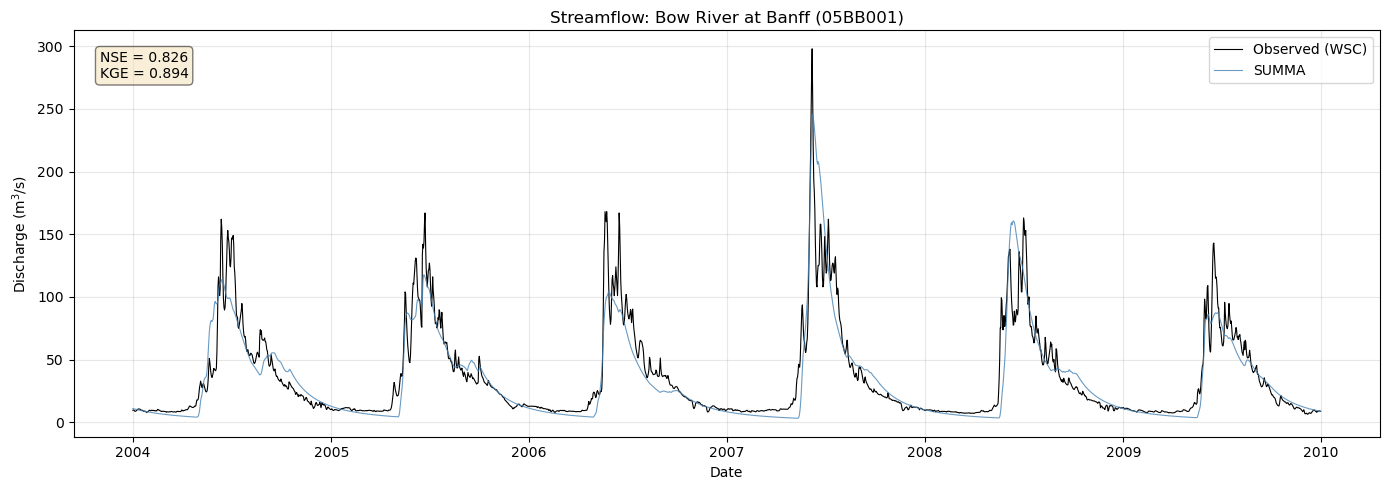

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(obs_aligned.index, obs_aligned[site_id], label="Observed (WSC)", color="black", linewidth=0.8)
ax.plot(mod_aligned.index, mod_aligned[site_id], label="SUMMA", color="steelblue", linewidth=0.8, alpha=0.8)

ax.set_xlabel("Date")
ax.set_ylabel("Discharge (m$^3$/s)")
ax.set_title(f"Streamflow: {site_name} ({site_id})")
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate with key metrics
nse_val = metrics_df["nse"].iloc[0]
kge_val = metrics_df["kge"].iloc[0]
ax.text(
    0.02, 0.95, f"NSE = {nse_val:.3f}\nKGE = {kge_val:.3f}",
    transform=ax.transAxes, fontsize=10, verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

plt.tight_layout()
plt.show()

### 1.7 Streamflow Diagnostics (3-panel)

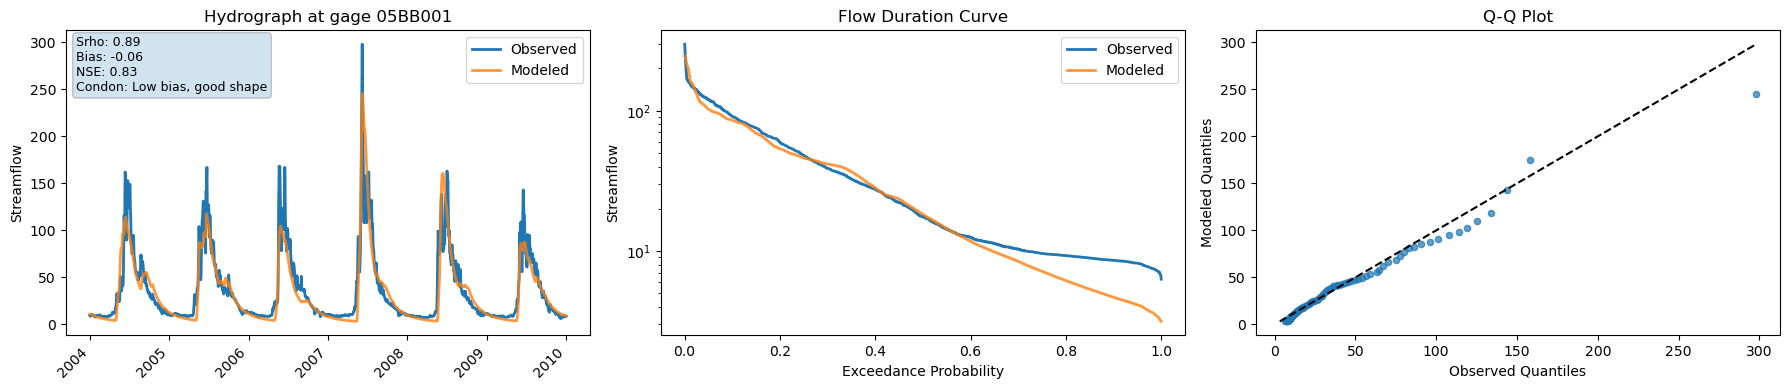

In [8]:
# Get the metrics row for annotation
metrics_row = metrics_df.iloc[0]

plot_streamflow_diagnostics(
    streamflow_data_df=obs_for_metrics,
    model_df=mod_for_metrics,
    site_id=site_id,
    metrics_row=metrics_row,
    output_dir=".",
)
plt.show()

### 1.8 Scatter plot

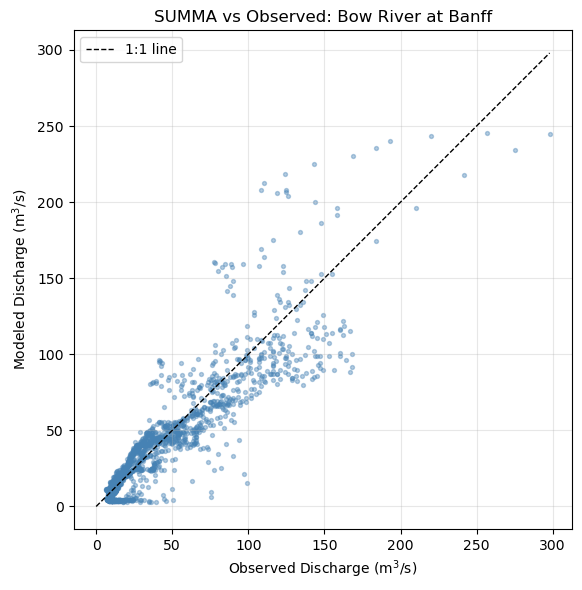

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

obs_vals = obs_aligned[site_id].values
mod_vals = mod_aligned[site_id].values

ax.scatter(obs_vals, mod_vals, s=8, alpha=0.4, color="steelblue")

# 1:1 line
max_val = max(obs_vals.max(), mod_vals.max())
ax.plot([0, max_val], [0, max_val], "k--", linewidth=1, label="1:1 line")

ax.set_xlabel("Observed Discharge (m$^3$/s)")
ax.set_ylabel("Modeled Discharge (m$^3$/s)")
ax.set_title(f"SUMMA vs Observed: {site_name}")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: Semi-Distributed SUMMA + mizuRoute Evaluation

For semi-distributed domains, SUMMA runs with multiple HRUs grouped into GRUs, and **mizuRoute** routes the runoff through a river network. The `get_mizuroute_streamflow()` function extracts routed discharge at a specific river segment.

Segment selection options:
- **`segment_id`**: Explicit reach ID
- **`latitude` + `longitude` + `river_network_shp`**: Nearest segment by geometry
- **Auto-outlet**: Segment with highest mean discharge (default)

### 2.1 Define Distributed Domain Paths

In [10]:
# Semi-distributed domain: 25 HRUs, 13 GRUs, 13 river segments
domain_distributed = "domain_Bow_at_Banff_elevation"
mizuroute_output_dir = os.path.join(
    symfluence_data, domain_distributed, "simulations", "multiyear_eval", "mizuRoute"
)
river_network_shp = os.path.join(
    symfluence_data, domain_distributed, "shapefiles", "river_network",
    "Bow_at_Banff_elevation_riverNetwork_semidistributed.shp"
)

# Outlet segment ID (from network topology)
outlet_segment_id = 25

print(f"Domain: {domain_distributed}")
print(f"mizuRoute output: {mizuroute_output_dir}")
print(f"Outlet segment: {outlet_segment_id}")

Domain: domain_Bow_at_Banff_elevation
mizuRoute output: /Users/darri.eythorsson/compHydro/SYMFLUENCE_data/domain_Bow_at_Banff_elevation/simulations/multiyear_eval/mizuRoute
Outlet segment: 25


### 2.2 Extract Routed Streamflow

Two approaches are shown:
1. **By segment ID** — directly specify the outlet reach
2. **By lat/lon** — find the nearest river segment to a gauge location

In [11]:
# Approach 1: Extract by segment ID
model_dist_df = get_mizuroute_streamflow(
    mizuroute_output_dir=mizuroute_output_dir,
    date_start=date_start,
    date_end=date_end,
    segment_id=outlet_segment_id,
    temporal_resolution="daily",
)
model_dist_df = model_dist_df.rename(columns={"streamflow": site_id})
print(f"By segment ID ({outlet_segment_id}):")
print(f"  Shape: {model_dist_df.shape}, Q range: {model_dist_df[site_id].min():.1f} - {model_dist_df[site_id].max():.1f} m³/s")

# Approach 2: Extract by lat/lon (gauge location near Banff)
model_latlon_df = get_mizuroute_streamflow(
    mizuroute_output_dir=mizuroute_output_dir,
    date_start=date_start,
    date_end=date_end,
    latitude=51.17,
    longitude=-115.57,
    river_network_shp=river_network_shp,
    temporal_resolution="daily",
)
print(f"\nBy lat/lon (51.17, -115.57):")
print(f"  Shape: {model_latlon_df.shape}, Q range: {model_latlon_df['streamflow'].min():.1f} - {model_latlon_df['streamflow'].max():.1f} m³/s")

By segment ID (25):
  Shape: (2192, 2), Q range: 1.6 - 68.6 m³/s

By lat/lon (51.17, -115.57):
  Shape: (2192, 2), Q range: 1.6 - 68.6 m³/s


### 2.3 Evaluate mizuRoute Streamflow

In [12]:
# Align distributed model with observations
obs_aligned_dist, mod_aligned_dist = align_dataframes_on_common_dates(
    obs_daily, model_dist_df, date_col_obs="date", date_col_mod="date"
)

# Calculate metrics
obs_for_dist = obs_aligned_dist.reset_index().rename(columns={obs_aligned_dist.index.name or "date": "date"})
mod_for_dist = mod_aligned_dist.reset_index().rename(columns={mod_aligned_dist.index.name or "date": "date"})

metrics_dist_df = calculate_metrics(
    obs_data_df=obs_for_dist,
    model_data_df=mod_for_dist,
    obs_metadata_df=obs_metadata_df,
    metrics_list=metrics_list,
)

metrics_dist_df

,site_id,site_name,latitude,longitude,rmse,nse,kge,pearson_r,spearman_rho,bias,percent_bias,abs_rel_bias,condon
0,05BB001,Bow River at Banff,51.36,-116.01,35.821344,0.102201,0.108384,0.729578,0.744747,-0.600181,-60.018133,0.600181,"Low bias, good shape"


### 2.4 Compare Lumped vs Distributed

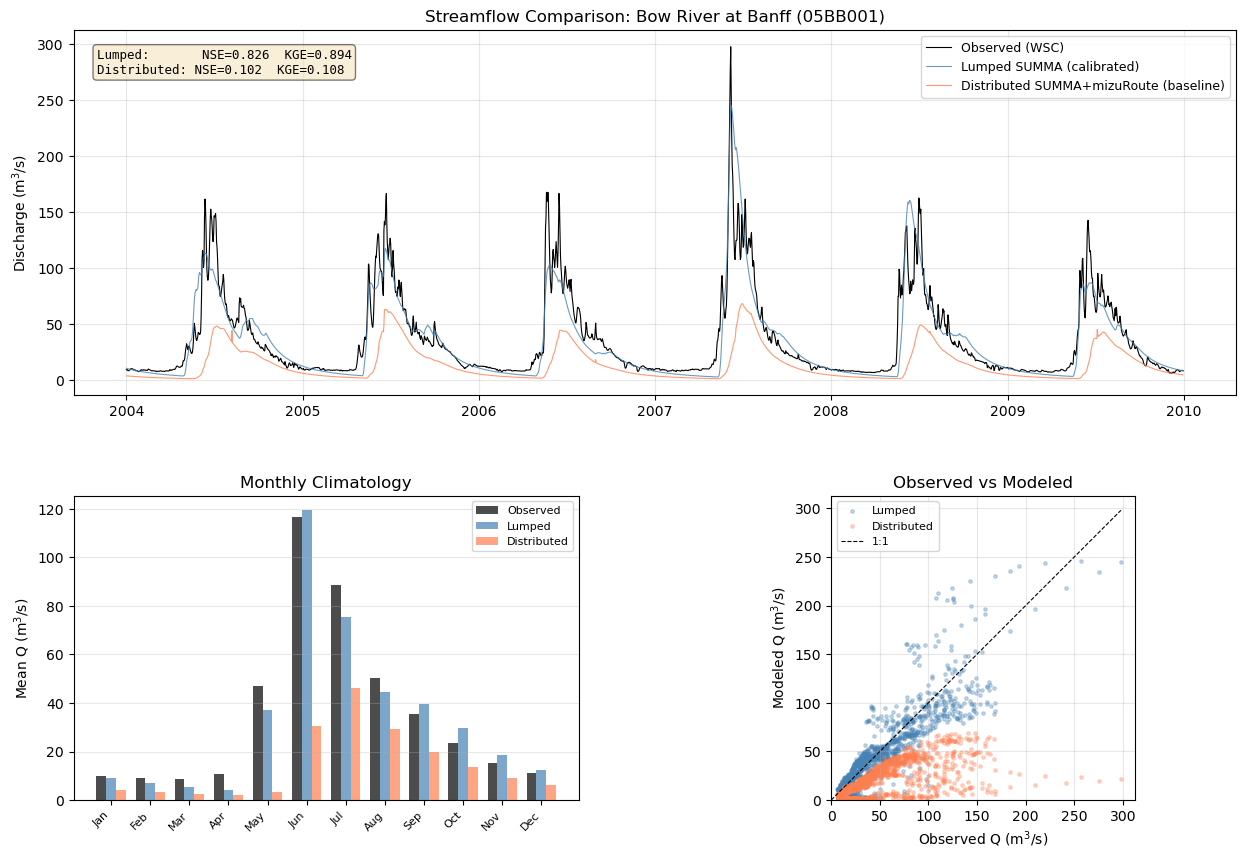

In [13]:
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.3)

# --- Panel 1: Hydrograph (full width) ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(obs_aligned.index, obs_aligned[site_id], label="Observed (WSC)", color="black", linewidth=0.8)
ax1.plot(mod_aligned.index, mod_aligned[site_id], label="Lumped SUMMA (calibrated)", color="steelblue", linewidth=0.8, alpha=0.8)
ax1.plot(obs_aligned_dist.index, mod_aligned_dist[site_id], label="Distributed SUMMA+mizuRoute (baseline)", color="coral", linewidth=0.8, alpha=0.8)
ax1.set_ylabel("Discharge (m$^3$/s)")
ax1.set_title(f"Streamflow Comparison: {site_name} ({site_id})")
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(True, alpha=0.3)

nse_l = metrics_df["nse"].iloc[0]
kge_l = metrics_df["kge"].iloc[0]
nse_d = metrics_dist_df["nse"].iloc[0]
kge_d = metrics_dist_df["kge"].iloc[0]
ax1.text(0.02, 0.95, f"Lumped:       NSE={nse_l:.3f}  KGE={kge_l:.3f}\nDistributed: NSE={nse_d:.3f}  KGE={kge_d:.3f}",
         transform=ax1.transAxes, fontsize=9, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# --- Panel 2: Monthly climatology (bottom left) ---
ax2 = fig.add_subplot(gs[1, 0])
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

obs_monthly = obs_aligned[site_id].groupby(obs_aligned.index.month).mean()
mod_monthly = mod_aligned[site_id].groupby(mod_aligned.index.month).mean()
dist_monthly = mod_aligned_dist[site_id].groupby(mod_aligned_dist.index.month).mean()

x = np.arange(12)
width = 0.25
ax2.bar(x - width, obs_monthly.values, width, label="Observed", color="black", alpha=0.7)
ax2.bar(x, mod_monthly.values, width, label="Lumped", color="steelblue", alpha=0.7)
ax2.bar(x + width, dist_monthly.values, width, label="Distributed", color="coral", alpha=0.7)
ax2.set_ylabel("Mean Q (m$^3$/s)")
ax2.set_title("Monthly Climatology")
ax2.set_xticks(x)
ax2.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=8)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis="y")

# --- Panel 3: Scatter comparison (bottom right) ---
ax3 = fig.add_subplot(gs[1, 1])
max_val = max(obs_aligned[site_id].max(), mod_aligned[site_id].max(), mod_aligned_dist[site_id].max())

ax3.scatter(obs_aligned[site_id], mod_aligned[site_id], s=6, alpha=0.3, color="steelblue", label="Lumped")
ax3.scatter(obs_aligned_dist[site_id], mod_aligned_dist[site_id], s=6, alpha=0.3, color="coral", label="Distributed")
ax3.plot([0, max_val], [0, max_val], "k--", linewidth=0.8, label="1:1")
ax3.set_xlabel("Observed Q (m$^3$/s)")
ax3.set_ylabel("Modeled Q (m$^3$/s)")
ax3.set_title("Observed vs Modeled")
ax3.legend(fontsize=8, loc="upper left")
ax3.set_aspect("equal")
ax3.set_xlim(0, max_val * 1.05)
ax3.set_ylim(0, max_val * 1.05)
ax3.grid(True, alpha=0.3)

plt.savefig("lumped_vs_distributed_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.5 Streamflow Diagnostics (Distributed)

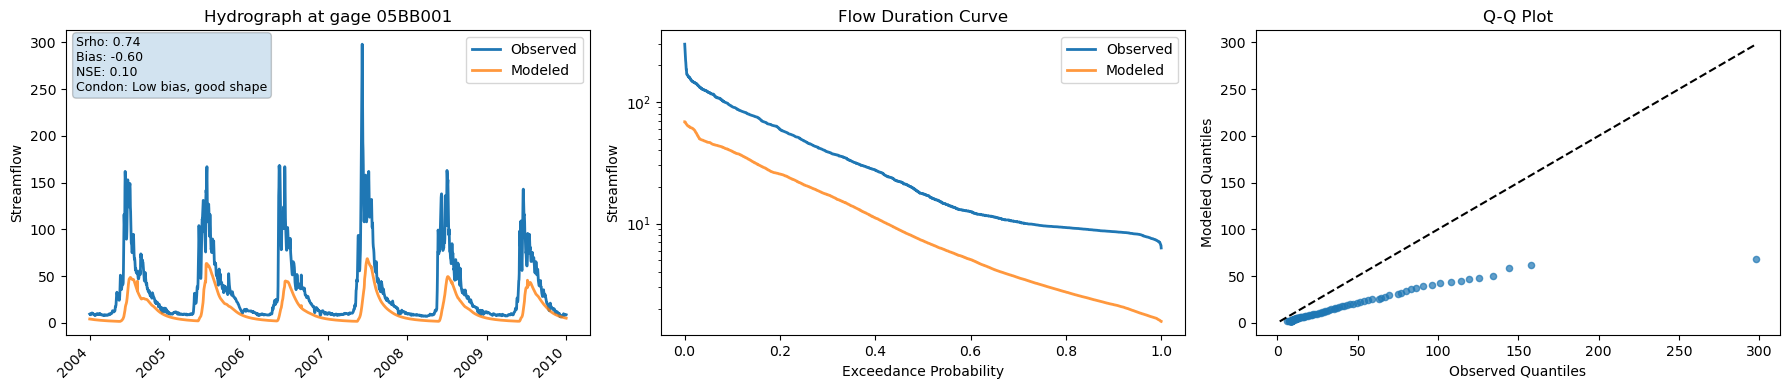

In [14]:
metrics_row_dist = metrics_dist_df.iloc[0]

plot_streamflow_diagnostics(
    streamflow_data_df=obs_for_dist,
    model_df=mod_for_dist,
    site_id=site_id,
    metrics_row=metrics_row_dist,
    output_dir=".",
)
plt.show()